<a href="https://colab.research.google.com/github/Zeshan811/StarterNotebookA1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"}

feature_frame = con.sql(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        AVG(gsc_avg_position) AS avg_position_month,
        (SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0)) AS ctr_month
    FROM {TABLES['fact_daily']}
    WHERE report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01'
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) >= 100
""").df()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["total_impressions", "total_clicks", "avg_position_month", "ctr_month"]
X = feature_frame[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_scaled)
feature_frame["cluster"] = kmeans.labels_

print(feature_frame.groupby("cluster")[features].mean().round(3))
print(feature_frame.groupby("cluster").size())

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         total_impressions  total_clicks  avg_position_month  ctr_month
cluster                                                                
0                 1594.827        16.511               8.550      0.012
1                25558.858        75.971              10.045      0.004
2                 1584.005         1.400              40.414      0.001
3               617124.000      5668.000               2.383      0.009
4                89101.071       506.450               5.676      0.008
5                 1930.041         4.140               9.253      0.002
cluster
0    10070
1     3363
2    17040
3        1
4      140
5    70827
dtype: int64


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



| Archetype | Reason code | Action |
|---|---|---|
| Champions — high traffic, strong position, solid CTR | stable_performer | protect — avoid disruptive changes |
| Hidden Gems — low volume, highest CTR of any real cluster | high_efficiency_low_reach | promote / expand — proven format, needs reach |
| Buried Pages — very deep position (40+), low CTR | visibility_gap | ranking/visibility work — not a metadata fix |
| Mid-Tier Visible — moderate on all fronts | steady_watch | monitor — no urgent action |
| Background/Low-Signal — low impressions/clicks/CTR (largest group) | low_demand | low priority — lightweight rule-based monitoring only |
| Outlier (single page) — extreme traffic, its own cluster | outlier_exclude | exclude from playbook — needs manual handling |

Within each archetype, pages are ranked by total_impressions — higher-demand
pages get reviewed first, since the cost of a wrong call is bigger when more
search demand is at stake.

In [3]:
archetype_map = {
    4: ("Champions", "stable_performer", "protect"),
    0: ("Hidden Gems", "high_efficiency_low_reach", "promote_expand"),
    2: ("Buried Pages", "visibility_gap", "visibility_review"),
    1: ("Mid-Tier Visible", "steady_watch", "monitor"),
    5: ("Background/Low-Signal", "low_demand", "low_priority_monitor"),
    3: ("Outlier", "outlier_exclude", "manual_review_only"),
}

feature_frame["archetype"] = feature_frame["cluster"].map(lambda c: archetype_map[c][0])
feature_frame["reason_code"] = feature_frame["cluster"].map(lambda c: archetype_map[c][1])
feature_frame["action"] = feature_frame["cluster"].map(lambda c: archetype_map[c][2])

ranked_queue = feature_frame.sort_values(
    ["archetype", "total_impressions"], ascending=[True, False]
).reset_index(drop=True)

ranked_queue.head(10)

,content_hash_id,total_impressions,total_clicks,avg_position_month,ctr_month,cluster,archetype,reason_code,action
0,content_65730162f49cecf5,18768.0,1.0,5.895139,0.000053,5,Background/Low-Signal,low_demand,low_priority_monitor
1,content_27490a2800021a2e,18737.0,1.0,13.959898,0.000053,5,Background/Low-Signal,low_demand,low_priority_monitor
2,content_4eda8031337c5b6b,18501.0,4.0,21.971406,0.000216,5,Background/Low-Signal,low_demand,low_priority_monitor
3,content_2cf38b0c66e6396c,18176.0,4.0,6.290687,0.000220,5,Background/Low-Signal,low_demand,low_priority_monitor
4,content_adfba6ae375e5bf3,18021.0,7.0,3.038978,0.000388,5,Background/Low-Signal,low_demand,low_priority_monitor
5,content_5f37bc769394835c,18003.0,7.0,1.657695,0.000389,5,Background/Low-Signal,low_demand,low_priority_monitor
6,content_3b5dbbc8e759f56b,17988.0,5.0,5.754183,0.000278,5,Background/Low-Signal,low_demand,low_priority_monitor
7,content_f57e4e8c0208f271,17973.0,9.0,1.602819,0.000501,5,Background/Low-Signal,low_demand,low_priority_monitor
8,content_9ad00a5b87282061,17931.0,9.0,4.497979,0.000502,5,Background/Low-Signal,low_demand,low_priority_monitor
9,content_b534d074a411c288,17920.0,7.0,4.395717,0.000391,5,Background/Low-Signal,low_demand,low_priority_monitor


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



**Who uses this:** a content review team deciding which pages to look at
first, given limited review capacity.

**Intended use:** a triage aid that sits alongside human judgment — never
a replacement for it.

**Where it stops being valid:**
- It reflects one month (March 2026) only — archetype membership can shift
  month to month.
- It cannot explain why a page ended up in an archetype (no causal claim).
- It cannot guarantee what happens if the suggested action is taken
  (no outcome guarantee).
- It says nothing about Google's ranking algorithm.
- It should not be used for clients/content whose tracking only partially
  covers this month (check gsc_data_start / ga4_data_start first).

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



**A person must check, before acting:**
- Whether the flagged page's low CTR could be explained by branded/
  navigational search intent (where low CTR is normal, not a real problem)
- Whether a "declining" or "buried" page is actually a consolidation case —
  i.e. a sibling URL on the same site absorbed its traffic (not a real loss)
- Whether the page's data reflects a full month or a partial-tracking window

**What should NEVER be automated from this output:**
- Auto-publishing rewritten titles/meta descriptions without a human reading them
- Auto-pruning or deleting any page based on the "Background/Low-Signal" or
  "Outlier" label alone
- Using this as a performance review of content creators/writers
- Using this as the sole input for a client-facing report without a human
  sanity check on the top candidates
- Auto-triggering any client billing or contractual action based on archetype labels

**No-go cases (extra scrutiny required):**
- Pages in the Outlier cluster (n=1) — statistically unreliable
- Pages with impressions right at a threshold boundary (e.g. just above 100)
- Any page where tracking start dates suggest partial-month data

In [4]:
import pandas as pd
for k_test in [5, 6, 7]:
    km_test = KMeans(n_clusters=k_test, random_state=42, n_init=10).fit(X_scaled)
    print(f"k={k_test}: cluster sizes = {sorted(pd.Series(km_test.labels_).value_counts().values, reverse=True)}")

k=5: cluster sizes = [np.int64(71100), np.int64(17122), np.int64(10094), np.int64(3041), np.int64(84)]
k=6: cluster sizes = [np.int64(70827), np.int64(17040), np.int64(10070), np.int64(3363), np.int64(140), np.int64(1)]
k=7: cluster sizes = [np.int64(58782), np.int64(20995), np.int64(16027), np.int64(3176), np.int64(2326), np.int64(134), np.int64(1)]


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



Re-run this playbook monthly — it should never be treated as a one-time output.

**Retrain triggers:**
- A new month's data becomes available (natural monthly cadence)
- Active client count changes by more than ~20% (panel composition shifted)
- A manual top-20 review finds reason codes no longer match what reviewers
  see in practice — a sign of cluster drift
- Silhouette score on a fresh month drops noticeably below the Week-6
  validated baseline

**Monitoring signal:** track cluster size distribution month to month (as
shown above for k=5/6/7 as a sensitivity check) — a sudden large shift in
how many pages fall into "Background/Low-Signal" vs other archetypes is
worth a manual look before trusting that month's recommendations.

Exported 101441 rows to work/outputs/action_playbook_queue.csv
Saved work/outputs/playbook_metrics.json


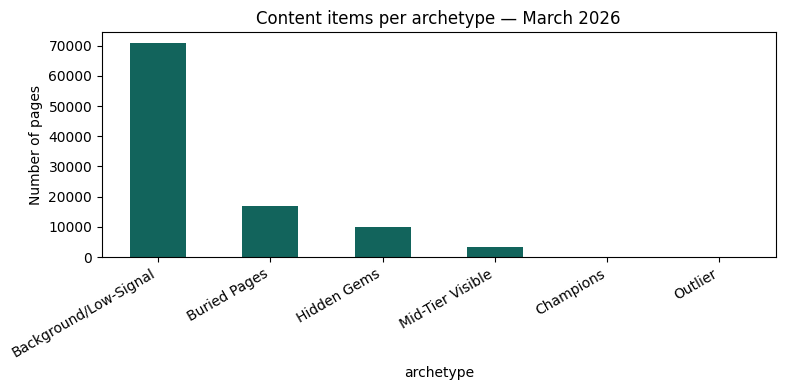

Saved work/figures/archetype_sizes.png


In [5]:
import os, json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = ["content_hash_id", "archetype", "reason_code", "action",
               "total_impressions", "total_clicks", "avg_position_month", "ctr_month"]
ranked_queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Exported {len(ranked_queue)} rows to work/outputs/action_playbook_queue.csv")

metrics = {
    "k": 6,
    "cluster_sizes": feature_frame.groupby("archetype").size().to_dict(),
    "cluster_means": feature_frame.groupby("archetype")[features].mean().round(4).to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved work/outputs/playbook_metrics.json")

sizes = feature_frame.groupby("archetype").size().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sizes.plot(kind="bar", color="#12645C")
plt.title("Content items per archetype — March 2026")
plt.ylabel("Number of pages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/archetype_sizes.png", dpi=150)
plt.show()
print("Saved work/figures/archetype_sizes.png")

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



- work/outputs/action_playbook_queue.csv — full ranked queue (regenerated
  each run, stays out of git per the CI leak-guard)
- work/outputs/playbook_metrics.json — cluster sizes and mean feature values
  (committed — the paper's Results table traces back to this)
- work/figures/archetype_sizes.png — bar chart of archetype sizes (committed,
  reused directly in the capstone paper)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.